# AI in science: When and where it makes a difference

<u>What this does</u>:  
This notebook runs a full pipeline to explore how AI affects scientific fields in terms of **impact** (citations, top-cited shares) and **novelty** (semantic distance, linguistic innovation).

It allows users to reproduce all analyses reported in the main text and Supplementary Materials, as well as additional investigations not necessarily included in the published paper.

This notebook was originally co-developed with ChatGPT in August 2025.  We take full responsibility for all code, analyses, and interpretations.

---

# 1. General trends 

The dataset, `df`, contains field-level observations used for the main analysis. 

Each observation corresponds to a scientific field and includes information on (i) the number of publications over time, (ii) the share of AI-related publications over time, and (iii) coefficient estimates from the regressions in Eq. (1).



In [1]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
# Load dataset
df = pd.read_csv("df_descriptives.csv")

In [3]:
# Concepts you may want to drop

# Less restrictive list (the one used for the main analysis)
drop_concepts = ["Algorithm", "Arithmetic", "Mathematical Analysis", 
                 "Mathematical Optimization", "Pure Mathematics", "Simulation", "Statistics"
                ]

# More restrictive list
# drop_concepts = ["Control Engineering", "Algorithm", "Applied Mathematics", 
#                  "Arithmetic", "Mathematical Analysis", 
#                  "Mathematical Optimization", "Pure Mathematics",
#                  "Simulation", "Statistics"
#                 ]

# set to True only when you want to apply filtering
APPLY_DROPS = True  

if APPLY_DROPS:
    df = df[~df["concept"].isin(drop_concepts)].reset_index(drop=True)

In [4]:
df

,concept,nb_publ,nb_ai_publ,share_ai_total,nb_publ_2005,nb_ai_publ_2005,share_ai_2005,nb_publ_2006,nb_ai_publ_2006,share_ai_2006,nb_publ_2007,nb_ai_publ_2007,share_ai_2007,nb_publ_2008,nb_ai_publ_2008,share_ai_2008,nb_publ_2009,nb_ai_publ_2009,share_ai_2009,nb_publ_2010,nb_ai_publ_2010,share_ai_2010,nb_publ_2011,nb_publ_2011.1,share_ai_2011,nb_publ_2012,nb_ai_publ_ 2012,share_ai_2012,nb_publ_2013,nb_ai_publ_2013,share_ai_2013,nb_publ_2014,nb_ai_publ_2014,share_ai_2014,nb_publ_2015,nb_ai_publ_2015,share_ai_2015,nb_publ_2016,nb_ai_publ_2016,share_ai_2016,nb_publ_2017,nb_ai_publ_2017,share_ai_2017,nb_publ_2018,nb_ai_publ_2018,share_ai_2018,nb_publ_2019,nb_ai_publ_2019,share_ai_2019,nb_publ_2020,nb_ai_publ_2020,share_ai_2020,nb_publ_2021,nb_ai_publ_2021,share_ai_2021,nb_publ_2022,nb_ai_publ_2022,share_ai_2022,nb_publ_2023,nb_ai_publ_2023,share_ai_2023,nb_publ_2024,nb_ai_publ_2024,share_ai_2024,weighted_nb_citations,weighted_nb_citations_se,top_cited_10,top_cited_10_se,top_cited_5,top_cited_5_se,top_cited_1,top_cited_se,semantic_distance,semantic_distance_se,new_word,new_word_se,new_word_comb,new_word_comb_se,new_phrase,new_phrase_se,new_phrase_comb,new_phrase_comb_se,parent_concept
0,Acoustics,2 049 947,546 037,0.2664,74 684,20 033,0.2682,81 407,21 740,0.2671,81 978,21 797,0.2659,88 511,24 165,0.2730,92 859,25 173,0.2711,100 905,27 449,0.2720,106 049,28 179,0.2657,107 766,28 603,0.2654,111 005,29 630,0.2669,110 559,28 925,0.2616,107 522,27 846,0.2590,107 327,27 375,0.2551,106 836,27 749,0.2597,110 580,28 666,0.2592,115 861,30 851,0.2663,111 794,30 214,0.2703,114 704,31 388,0.2736,106 893,29 717,0.2780,114 219,32 819,0.2873,98 488,23 718,0.2408,0.000,0.001,0.071***,0.006,0.114***,0.008,0.174***,0.017,0.011***,0.000,0.050***,0.012,0.163***,0.005,0.141***,0.006,0.269***,0.005,Physics
1,Aeronautics,338 209,46 410,0.1372,13 919,1 757,0.1262,14 160,1 797,0.1269,14 027,1 856,0.1323,15 302,1 936,0.1265,15 344,1 966,0.1281,16 009,2 090,0.1306,17 146,2 257,0.1316,17 090,2 306,0.1349,18 883,2 381,0.1261,18 931,2 393,0.1264,21 053,2 439,0.1159,22 971,2 539,0.1105,20 825,2 587,0.1242,19 424,2 603,0.1340,20 123,2 772,0.1378,17 697,2 490,0.1407,14 102,2 168,0.1537,11 326,1 974,0.1743,12 134,2 402,0.1980,17 743,3 697,0.2084,0.020***,0.002,0.134***,0.018,0.143***,0.022,0.247***,0.043,0.004***,0.001,0.156***,0.048,0.252***,0.020,NaN,NaN,0.433***,0.021,Engineering
2,Aerospace Engineering,1 582 882,424 593,0.2682,53 251,12 282,0.2306,58 966,14 043,0.2382,60 466,14 568,0.2409,65 058,15 815,0.2431,70 557,17 363,0.2461,76 542,19 374,0.2531,82 418,21 045,0.2553,82 505,20 952,0.2539,85 746,21 869,0.2550,85 724,22 352,0.2607,82 632,21 072,0.2550,81 889,20 759,0.2535,82 851,21 347,0.2577,87 381,23 654,0.2707,92 378,25 728,0.2785,91 415,26 780,0.2929,90 527,28 263,0.3122,84 938,28 095,0.3308,92 497,30 811,0.3331,75 141,18 421,0.2452,-0.004***,0.001,0.042***,0.007,0.084***,0.009,0.232***,0.018,0.008***,0.000,0.004,0.014,0.129***,0.006,0.111***,0.007,0.244***,0.006,Engineering
3,Agricultural Engineering,142 058,20 900,0.1471,3 624,355,0.0980,3 829,435,0.1136,4 335,487,0.1123,5 011,510,0.1018,5 998,638,0.1064,6 780,711,0.1049,6 278,646,0.1029,6 622,707,0.1068,6 828,741,0.1085,7 086,738,0.1041,6 887,724,0.1051,6 037,662,0.1097,6 613,748,0.1131,7 648,974,0.1274,8 297,1 295,0.1561,9 178,1 525,0.1662,9 593,1 923,0.2005,9 296,2 072,0.2229,10 779,2 743,0.2545,11 339,2 266,0.1998,0.075***,0.003,0.462***,0.027,0.520***,0.034,0.612***,0.068,0.015***,0.001,-0.024,0.063,0.076***,0.025,0.032,0.031,0.177***,0.026,Engineering
4,Agricultural Science,229 333,9 882,0.0431,4 752,232,0.0488,5 127,252,0.0492,5 724,226,0.0395,6 868,284,0.0414,8 175,349,0.0427,9 112,381,0.0418,9 125,377,0.0413,10 249,434,0.0423,11 708,514,0.0439,12 700,576,0.0454,13 343,528,0.0396,12 670,553,0.0436,13 188,451,0.0342,15 387,591,0.0384,15 796,696,0.0441,17 699,814,0.0460,17 349,790,0.0455,15 088,742,0.0492,15 747,703,0.0446,9 526,389,0.0408,0.001,0.004,0.008,0.039,-0.036,0.050,-0.138,0.103,0.012***,0.

---

## Plots 

<u>What the dashboard shows</u>:  
This 6-panel figure combines complementary views of AI adoption across science:  

- **Panel A**: Total AI publications (blue, left axis) and overall AI share (red, right axis).  
  → Shows the aggregate trajectory of AI in science since 2005.  

- **Panel B**: Scatter of fields by average YoY growth (2005–2023) vs. AI share in 2023.  
  → Blue highlights = top growth fields; Orange highlights = top share fields.  
  → Reveals the trade-off between *emerging fast* vs. *already large*.  

- **Panels C–D (YoY growth):** Top-K concepts ranked by *average year-on-year growth*.  
  - C: Line plot with trajectories (all fields grey, top-K highlighted).  
  - D: Bar chart ranking fields by average annual growth.  

- **Panels E–F (Absolute growth):** Top-K concepts ranked by *absolute change in AI share* between start and end years.  
  - E: Line plot of trajectories (grey vs highlighted).  
  - F: Bar chart of total gains in percentage points.  

<u>How to read it</u>:  
- **High in both growth and absolute** → AI “hotspots” (fast and large adoption).  
- **High in growth but low absolute** → fast-emerging but still small.  
- **High in absolute but low growth** → established, large fields with slower momentum.  

<u>Customization notes</u>:  

- **Panel A:**  
  - Years: adjust `YEARS`.  
  - Scale of right axis: let Python auto-choose or fix with `ax2.set_ylim()`.  

- **Panel B:**  
  - `TOP_K_GROWTH` and `TOP_K_SHARE` control highlighted fields.  
  - `X_MAX` and `Y_MAX` control axis limits.  
  - Label placement adjusted via `place_labels_greedy()`.  

- **Panels C–F:**  
  - `START_GROWTH` / `END_GROWTH` set the YoY growth window.  
  - `START_ABS` / `END_ABS` set the absolute growth window.  
  - `TOP_K` controls how many concepts are highlighted.  
  - `min_gap` tunes spacing between right-hand labels.  

Panels A–B provide the **big picture** of aggregate AI adoption and the **positioning of fields**, while Panels C–F dig deeper into the **trajectories and rankings** of the top movers.  

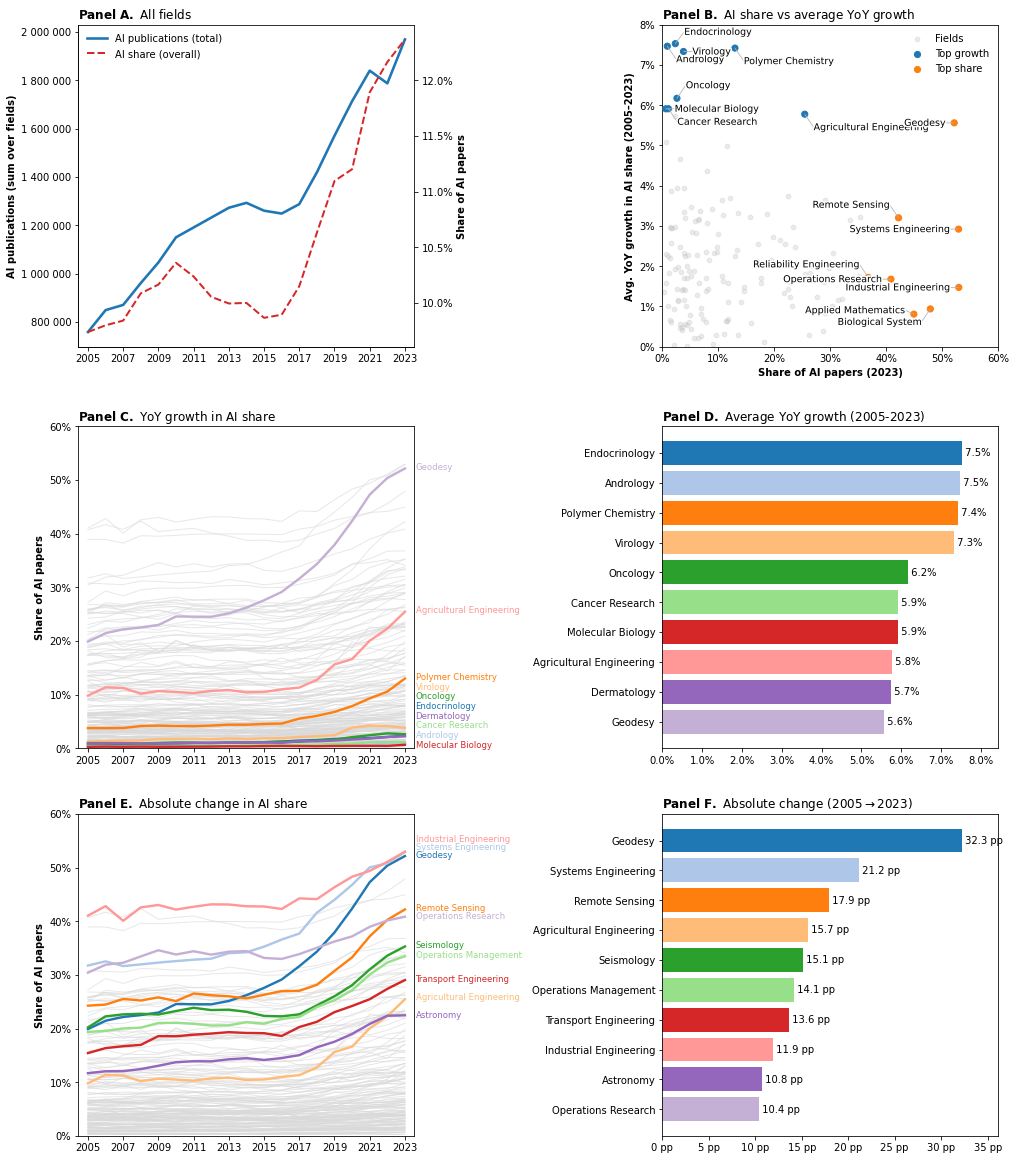

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as pe
import re

# -------------------------
# Global config
# -------------------------
YEARS = list(range(2005, 2023 + 1))    # 2005–2023
TOP_K_GROWTH = 8                       # Panel B: #labels for top growth
TOP_K_SHARE  = 8                       # Panel B: #labels for top share
X_MAX = 0.60                           # Panel B: x-limit for share
Y_MAX = 0.08                           # Panel B: y-limit for YoY growth
SAVE = True                            # export PNG/PDF at the end

# Dashboard (Panels C–F) settings
yoy_cfg = dict(TOP_K=10, START=2005, END=2023, x_offset=0.6, nudge=0.12, ymax=0.60, pad=0.005, min_gap=0.018)
abs_cfg = dict(TOP_K=10, START=2005, END=2023, x_offset=0.6, nudge=0.12, ymax=0.60, pad=0.005, min_gap=0.015)

# -------------------------
# Utilities
# -------------------------
def _clean_numeric_frame(frame):
    """Remove spaces/commas and coerce to numeric (keeps NaNs)."""
    clean = frame.replace({r"[^\d.\-]": ""}, regex=True).replace("", np.nan)
    return clean.apply(pd.to_numeric, errors="coerce")

def _points_to_data_y(ax, dy_pts):
    """Convert vertical offset in points to data-space for current axis."""
    inv = ax.transData.inverted()
    x0, y0 = ax.transData.transform((0, 0))
    x1, y1 = x0, y0 + dy_pts * (ax.figure.dpi / 72.0)
    _, y_data = inv.transform((x1, y1))
    return y_data

def _label_cost(ax, xs, ys, ys_lab, crowd_gap=0.006, out_penalty=10.0, crowd_penalty=5.0):
    """Cost function to evaluate label placement (penalize out-of-bounds, crowding, and long arrows)."""
    xmin, xmax = ax.get_xlim(); ymin, ymax = ax.get_ylim()
    out = np.maximum(0, ymin - ys_lab) + np.maximum(0, ys_lab - ymax)
    ys_sorted = np.sort(ys_lab)
    crowd = np.sum(np.maximum(0.0, crowd_gap - np.diff(ys_sorted)))
    arrow = np.mean(np.abs(ys_lab - ys))
    return out_penalty*np.sum(out) + crowd_penalty*crowd + arrow

def place_labels_greedy(ax, xs, ys, CANDIDATE_DY_PTS=(-12,-8,-6,-4,-2,0,2,4,6,8,12), crowd_gap=0.006):
    """Greedy search over vertical offsets (in pts) to place labels with minimal overlap."""
    dy_data = np.array([_points_to_data_y(ax, d) for d in CANDIDATE_DY_PTS])
    n = len(xs)
    order = np.argsort(-ys)  # label highest y first
    ys_lab = ys.copy()
    chosen_idx = np.zeros(n, dtype=int)
    for k in order:
        best_c, best_j, best_y = None, 0, ys[k]
        for j, d in enumerate(dy_data):
            trial = ys_lab.copy()
            trial[k] = ys[k] + d
            c = _label_cost(ax, xs, ys, trial, crowd_gap=crowd_gap)
            if (best_c is None) or (c < best_c):
                best_c, best_j, best_y = c, j, ys[k] + d
        chosen_idx[k] = best_j
        ys_lab[k] = best_y
    return [CANDIDATE_DY_PTS[j] for j in chosen_idx]

def _safe_annotate(ax, x, y, text, dx_pts=6, dy_pts=0, color="black", ha="left"):
    """Place a text label with small arrow; clamp inside the axis box; add a white halo for readability."""
    inv = ax.transData.inverted()
    px, py = ax.transData.transform((x, y))
    px += dx_pts * (ax.figure.dpi / 72.0)
    py += dy_pts * (ax.figure.dpi / 72.0)
    x_lab, y_lab = inv.transform((px, py))
    x_min, x_max = ax.get_xlim(); y_min, y_max = ax.get_ylim()
    epsx = 0.01*(x_max-x_min); epsy = 0.01*(y_max-y_min)
    x_lab = np.clip(x_lab, x_min+epsx, x_max-epsx)
    y_lab = np.clip(y_lab, y_min+epsy, y_max-epsy)
    ax.annotate("", xy=(x_lab, y_lab), xytext=(x, y),
                arrowprops=dict(arrowstyle="-", color="0.7", lw=0.8, shrinkA=0, shrinkB=0),
                zorder=4)
    halo = [pe.withStroke(linewidth=3, foreground="white")]
    ax.text(x_lab, y_lab, text, fontsize=9.5, ha=ha, va="center",
            color=color, path_effects=halo, zorder=5)

def cmap_for(items):
    palette = plt.cm.tab20.colors
    return {c: palette[i % len(palette)] for i, c in enumerate(items)}

def stack_with_min_gap(y_vals, ymin, ymax, gap):
    """Right-side label helper (Panels C/E): minimally spaced stack of y-positions."""
    if len(y_vals) == 0:
        return np.array([])
    order = np.argsort(y_vals)
    ys = np.array(y_vals)[order].copy()
    for i in range(1, len(ys)):
        ys[i] = max(ys[i], ys[i-1] + gap)
    ys[-1] = min(ys[-1], ymax)
    for i in range(len(ys)-2, -1, -1):
        ys[i] = min(ys[i], ys[i+1] - gap)
    if ys[0] < ymin:
        shift = (ymin - ys[0])
        ys += shift
        ys[-1] = min(ys[-1], ymax)
    out = np.empty_like(ys)
    out[order] = ys
    return out

# -------------------------
# Data prep for Panel A
# -------------------------
# Expect df with columns: concept, nb_ai_publ_YYYY, share_ai_YYYY, nb_publ_YYYY
nb_ai_cols    = [f"nb_ai_publ_{y}" for y in YEARS if f"nb_ai_publ_{y}" in df.columns]
share_ai_cols = [f"share_ai_{y}"   for y in YEARS if f"share_ai_{y}"   in df.columns]
nb_tot_cols   = [f"nb_publ_{y}"    for y in YEARS if f"nb_publ_{y}"    in df.columns]

if nb_ai_cols:    df[nb_ai_cols]    = _clean_numeric_frame(df[nb_ai_cols])
if share_ai_cols: df[share_ai_cols] = df[share_ai_cols].apply(pd.to_numeric, errors="coerce")
if nb_tot_cols:   df[nb_tot_cols]   = _clean_numeric_frame(df[nb_tot_cols])

nb_ai_long = df.melt(id_vars="concept", value_vars=nb_ai_cols,
                     var_name="year", value_name="nb_ai")
nb_ai_long["year"] = nb_ai_long["year"].str.extract(r"(\d{4})").astype(int)
total_ai_per_year = (
    nb_ai_long.groupby("year", as_index=False)["nb_ai"]
              .sum(min_count=1)
              .sort_values("year")
)

# Weighted overall share across fields each year (weight by nb_publ_y when available)
overall_share = []
for y in sorted(int(c.split("_")[-1]) for c in share_ai_cols):
    s = pd.to_numeric(df[f"share_ai_{y}"], errors="coerce")
    if f"nb_publ_{y}" in df.columns:
        w = pd.to_numeric(df[f"nb_publ_{y}"], errors="coerce")
        num = (s * w).sum(min_count=1); den = w.sum(min_count=1)
        ov = num / den if den and not np.isnan(den) else np.nan
    else:
        ov = s.mean()
    overall_share.append((y, ov))
overall_share = pd.DataFrame(overall_share, columns=["year", "ai_share"]).sort_values("year")

# -------------------------
# Data prep for Panel B + C–F
# -------------------------
share_cols = [f"share_ai_{y}" for y in range(2005, 2024) if f"share_ai_{y}" in df.columns]
df[share_cols] = df[share_cols].apply(pd.to_numeric, errors="coerce")

def fields_df_for_B(df):
    """Compute avg YoY growth (2005–2023) and 2023 share for each concept."""
    long = df[["concept"] + share_cols].melt(id_vars="concept", var_name="year", value_name="share")
    long["year"] = long["year"].str.extract(r"(\d{4})").astype(int)
    long = long.query("year <= 2023").sort_values(["concept","year"])
    long["growth"] = long.groupby("concept", group_keys=False)["share"].pct_change()
    out = (long.groupby("concept", as_index=False)
                .agg(avg_yoy=("growth","mean"),
                     share_2023=("share", lambda s: s.iloc[-1])))
    # If a clean final-year column exists, prefer it (identical in most cases)
    if "share_ai_2023" in df.columns:
        out["share_2023"] = df["share_ai_2023"].values
    return out

df_B = fields_df_for_B(df)

df_long = (
    df.melt(id_vars="concept", value_vars=share_cols,
            var_name="year", value_name="share")
      .assign(year=lambda d: d["year"].str.extract(r"(\d{4})").astype(int))
      .query("year <= 2023")
      .sort_values(["concept","year"])
)

# -------------------------
# Panel-specific plotters
# -------------------------
def plot_panel_A(ax):
    """Panel A: AI volume (left axis, solid) + overall AI share (right axis, dashed, in %)."""
    fmt_thousands = lambda x: f"{int(x):,}".replace(",", " ")

    # Left axis: total AI publications
    ax.plot(
        total_ai_per_year["year"], total_ai_per_year["nb_ai"],
        lw=2.6, color="tab:blue", label="AI publications (total)"
    )
    ax.set_title(r"$\bf{Panel\ A.}$ All fields", loc="left")
    ax.set_xlabel("", fontweight="bold")
    ax.set_ylabel("AI publications (sum over fields)", fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: fmt_thousands(x)))
    ax.set_xticks(range(YEARS[0], YEARS[-1] + 1, 2))
    ax.tick_params(axis="x", rotation=0)  # horizontal years

    # Right axis: AI share (%)
    ax2 = ax.twinx()
    ax2.plot(
        overall_share["year"], overall_share["ai_share"] * 100.0,
        lw=2.0, ls="--", color="tab:red", label="AI share (overall)"
    )
    ax2.set_ylabel("Share of AI papers", fontweight="bold")
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.1f}%"))
    
    # Legend (combined)
    l1, lab1 = ax.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax2.legend(l1 + l2, lab1 + lab2, frameon=False, loc="upper left")

    # Style
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.margins(x=0.03)

def plot_panel_B(ax):
    """Panel B: Scatter of 2023 share vs avg YoY growth; highlight Top-K by growth (blue) and share (orange)."""
    dat = df_B[(df_B["share_2023"] >= 0) & (df_B["avg_yoy"].between(0, 0.10))].copy()

    # identify top growth & top share
    growth_idx = dat["avg_yoy"].nlargest(TOP_K_GROWTH).index
    share_idx  = dat.loc[dat["share_2023"] <= X_MAX, "share_2023"].nlargest(TOP_K_SHARE).index
    hi = dat.loc[growth_idx.union(share_idx)].copy()
    hi["color"] = np.where(hi.index.isin(growth_idx), "tab:blue", "tab:orange")

    # base scatter
    ax.scatter(dat["share_2023"], dat["avg_yoy"], s=22, color="0.78", alpha=0.35, label="Fields", zorder=1)
    # highlighted points
    ax.scatter(hi["share_2023"], hi["avg_yoy"], s=38, c=hi["color"], zorder=3)

    # auto-offset labels (blue = left labels; orange near right edge switch to right labels)
    hi_g = hi[hi["color"] == "tab:blue"]
    dy_g = place_labels_greedy(ax, hi_g["share_2023"].values, hi_g["avg_yoy"].values,
                               CANDIDATE_DY_PTS=(-10, -6, -3, 0, 3, 6, 10))
    for (idx, row), dy in zip(hi_g.iterrows(), dy_g):
        _safe_annotate(ax, row["share_2023"], row["avg_yoy"], row["concept"],
                       dx_pts=6, dy_pts=dy, color="black", ha="left")

    hi_s = hi[hi["color"] == "tab:orange"]
    dy_s = place_labels_greedy(ax, hi_s["share_2023"].values, hi_s["avg_yoy"].values,
                               CANDIDATE_DY_PTS=(-10, -6, -3, 0, 3, 6, 10))
    for (idx, row), dy in zip(hi_s.iterrows(), dy_s):
        dx = -6 if row["share_2023"] > 0.55 * X_MAX else 6
        _safe_annotate(ax, row["share_2023"], row["avg_yoy"], row["concept"],
                       dx_pts=dx, dy_pts=dy, color="black", ha=("right" if dx < 0 else "left"))

    # axes, labels, legend
    ax.set_xlim(0, X_MAX); ax.set_ylim(0, Y_MAX)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0%}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, p: f"{y:.0%}"))
    ax.set_xlabel("Share of AI papers (2023)", fontweight="bold")
    ax.set_ylabel("Avg. YoY growth in AI share (2005–2023)", fontweight="bold")
    ax.set_title(r"$\bf{Panel\ B.}$ AI share vs average YoY growth", loc="left")
    ax.scatter([], [], s=38, color="tab:blue",   label="Top growth")
    ax.scatter([], [], s=38, color="tab:orange", label="Top share")
    ax.legend(loc="upper right", frameon=False)

def plot_trends(ax, dfl, top_list, colors, x_start, x_end, x_offset, nudge, ymax, pad, min_gap):
    """Used in Panels C/E: spaghetti plot + highlight top-K with right-edge labels."""
    # background spaghetti
    for _, sub in dfl.groupby("concept", sort=False):
        ax.plot(sub["year"], sub["share"], color="0.85", lw=1, alpha=0.6)
    # highlights
    for c in top_list:
        sub = dfl.loc[dfl["concept"] == c].sort_values("year")
        ax.plot(sub["year"], sub["share"], lw=2.4, color=colors[c])

    # right-side label coordinates at x_end with slope-based nudge
    names, y_cand = [], []
    for c in top_list:
        sub = dfl.loc[dfl["concept"] == c]
        row_end = sub.loc[sub["year"] == x_end]
        if row_end.empty:
            continue
        y_end = row_end["share"].iloc[0]
        row_prev = sub.loc[sub["year"] == (x_end - 1)]
        dy = ((y_end - row_prev["share"].iloc[0]) if not row_prev.empty else 0.0) * nudge
        y0 = np.clip(y_end + dy, 0 + pad, ymax - pad)
        names.append(c); y_cand.append(y0)

    if names:
        y_stacked = stack_with_min_gap(y_cand, ymin=0 + pad, ymax=yoy_cfg["ymax"] - pad, gap=min_gap)
        for c, ylab in zip(names, y_stacked):
            ax.text(x_end + x_offset, ylab, c, fontsize=8.5, va="center", color=colors[c])

    # axes
    ax.set_xlabel("Year", fontweight="bold")
    ax.set_xticks(range(x_start, x_end + 1, 2))
    ax.set_ylabel("Share of AI papers", fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0%}"))
    ax.set_ylim(0, ymax)
    ax.margins(x=0.03)

def plot_bars(ax, items, values, colors, xfmt, labelfmt):
    """Used in Panels D/F: horizontal bars with value labels."""
    bars = ax.barh(items, values, color=[colors[c] for c in items])
    ax.invert_yaxis()
    ax.margins(x=0.12)
    ax.xaxis.set_major_formatter(xfmt)
    for b in bars:
        v = b.get_width()
        ax.text(v, b.get_y() + b.get_height()/2, labelfmt(v),
                va="center", ha="left", clip_on=False)
    ax.set_xlabel("", fontweight="bold")
    ax.set_ylabel("", fontweight="bold")

# -------------------------
# Compute ranks for Panels C–F
# -------------------------
# YoY growth ranking (C/D)
d_yoy = df_long[(df_long["year"] >= yoy_cfg["START"]) & (df_long["year"] <= yoy_cfg["END"])].copy()
d_yoy["growth_rate"] = d_yoy.groupby("concept", group_keys=False)["share"].pct_change()
d_yoy["growth_rate"] = d_yoy["growth_rate"].replace([np.inf, -np.inf], np.nan)
yoy_rank = (d_yoy.groupby("concept", as_index=False)["growth_rate"]
                 .mean()
                 .rename(columns={"growth_rate": "avg_growth"})
                 .sort_values("avg_growth", ascending=False)
                 .head(yoy_cfg["TOP_K"]))
yoy_list = yoy_rank["concept"].tolist()
yoy_colors = cmap_for(yoy_list)

# Absolute change ranking (E/F)
d_abs = df_long[(df_long["year"] >= abs_cfg["START"]) & (df_long["year"] <= abs_cfg["END"])].copy()
base = d_abs.loc[d_abs["year"] == abs_cfg["START"], ["concept", "share"]].rename(columns={"share": "s_start"})
last = d_abs.loc[d_abs["year"] == abs_cfg["END"],   ["concept", "share"]].rename(columns={"share": "s_end"})
abs_rank = (base.merge(last, on="concept", how="inner")
                 .dropna()
                 .assign(abs_change=lambda t: t["s_end"] - t["s_start"])
                 .sort_values("abs_change", ascending=False)
                 .head(abs_cfg["TOP_K"]))
abs_list = abs_rank["concept"].tolist()
abs_colors = cmap_for(abs_list)

# -------------------------
# Build the 3×2 layout (Panels A–F)
# -------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.08)  # increase vertical padding

# Row 1: A, B
plot_panel_A(axes[0, 0])
plot_panel_B(axes[0, 1])

# Row 2: C (trends YoY), D (bars YoY)
axes[1, 0].set_title(r"$\bf{Panel\ C.}$ YoY growth in AI share", loc="left")
plot_trends(
    ax=axes[1, 0], dfl=df_long, top_list=yoy_list, colors=yoy_colors,
    x_start=yoy_cfg["START"], x_end=yoy_cfg["END"],
    x_offset=yoy_cfg["x_offset"], nudge=yoy_cfg["nudge"],
    ymax=yoy_cfg["ymax"], pad=yoy_cfg["pad"], min_gap=yoy_cfg["min_gap"]
)
axes[1, 0].set_xlabel("")  # drop "Year" label in Panel C

axes[1, 1].set_title(r"$\bf{Panel\ D.}$ Average YoY growth (2005-2023)", loc="left")
plot_bars(
    ax=axes[1, 1],
    items=yoy_rank["concept"],
    values=yoy_rank["avg_growth"],
    colors=yoy_colors,
    xfmt=FuncFormatter(lambda x, p: f"{x:.1%}"),
    labelfmt=lambda v: f" {v:.1%}"
)

# Row 3: E (trends abs), F (bars abs)
axes[2, 0].set_title(r"$\bf{Panel\ E.}$ Absolute change in AI share", loc="left")
plot_trends(
    ax=axes[2, 0], dfl=df_long, top_list=abs_list, colors=abs_colors,
    x_start=abs_cfg["START"], x_end=abs_cfg["END"],
    x_offset=abs_cfg["x_offset"], nudge=abs_cfg["nudge"],
    ymax=abs_cfg["ymax"], pad=abs_cfg["pad"], min_gap=abs_cfg["min_gap"]
)
axes[2, 0].set_xlabel("")  # drop "Year" label in Panel E

axes[2, 1].set_title(r"$\bf{Panel\ F.}$ Absolute change (2005$\rightarrow$2023)", loc="left")
plot_bars(
    ax=axes[2, 1],
    items=abs_rank["concept"],
    values=abs_rank["abs_change"],
    colors=abs_colors,
    xfmt=FuncFormatter(lambda x, p: f"{x*100:.0f} pp"),
    labelfmt=lambda v: f" {v*100:.1f} pp"
)

# Export
if SAVE:
    fig.savefig("Figure_2.png", dpi=300, bbox_inches="tight")
    fig.savefig("Figure_2.pdf", bbox_inches="tight")

plt.show()

---

# 2. The effect of AI on creativity

<u>What the dashboard shows</u>:  
This 6-panel figure summarizes the regression-based relationship between AI adoption and two dimensions of scientific performance (**novelty** and **impact**) across fields.

- **Panel A (Novelty):** Share of positive, negative, and non-significant coefficients across five novelty indicators (semantic distance, new words, and new phrase combinations).  
  → Indicates how often AI adoption is associated with *increases* (green), *decreases* (orange), or *no detectable change* (grey) in novelty metrics.

- **Panel B (Impact):** Corresponding shares for impact indicators (weighted citations and top-cited thresholds).  
  → Provides a parallel view for citation-based outcomes.

- **Panels C–D (Top 20):** Fields showing the strongest *positive* coefficients.  
  - **C:** Top fields for novelty.  
  - **D:** Top fields for impact.  
  → These are domains where AI adoption most strongly correlates with higher novelty or impact.

- **Panels E–F (Bottom 20):** Fields showing the strongest *negative* coefficients.  
  - **E:** Bottom fields for novelty.  
  - **F:** Bottom fields for impact.  
  → These correspond to areas where AI adoption is most negatively associated with performance.

<u>How to read it</u>:  
- **Bars above zero** indicate fields where AI adoption is linked to *positive effects*.  
- **Bars below zero** (orange) indicate *negative effects*.  
- The **distribution of shares** (Panels A–B) reveals whether the effect is generally beneficial or mixed.  
- The **field rankings** (Panels C–F) identify *where* those effects are concentrated — e.g., biomedical vs. engineering domains.

<u>Customization notes</u>:  
- The degree of significance is controlled by `classify_coef()` (currently `p < 0.10`).  
- `TOP_N` adjusts how many fields appear in Panels C–F.  
- `SIGN_ONLY` filters to only significant coefficients.  
- `ABS_MAG` switches between ranking by signed or absolute values.  
- Layout ratios and font styles can be tuned via the `GridSpec` and fontweight options.

Panels A–B provide the **aggregate distribution of effects**, while Panels C–F reveal the **disciplinary heterogeneity** — highlighting which scientific domains benefit or lag most from AI adoption.


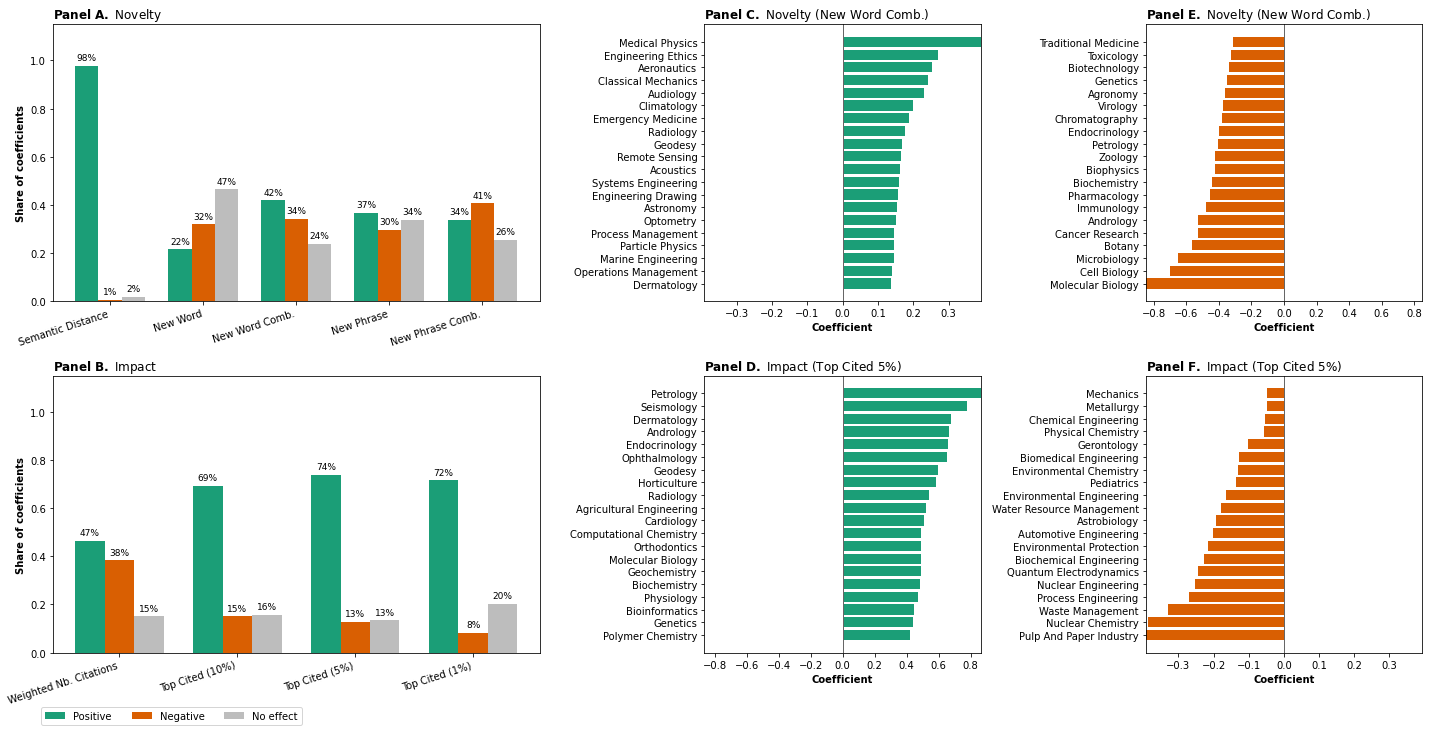

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.gridspec import GridSpec

# -------------------------
# Configuration 
# -------------------------
TOP_N = 20
SIGN_ONLY = True    
ABS_MAG   = False   

# Columns + Labels
impact_cols   = ["weighted_nb_citations", "top_cited_10", "top_cited_5", "top_cited_1"]
impact_labels = {
    "weighted_nb_citations": "Weighted Nb. Citations",
    "top_cited_10": "Top Cited (10%)",
    "top_cited_5": "Top Cited (5%)",
    "top_cited_1": "Top Cited (1%)"
}
impact_order  = ["weighted_nb_citations", "top_cited_10", "top_cited_5", "top_cited_1"]

novelty_cols   = ["semantic_distance", "new_word", "new_word_comb", "new_phrase", "new_phrase_comb"]
novelty_labels = {
    "semantic_distance": "Semantic Distance",
    "new_word": "New Word",
    "new_word_comb": "New Word Comb.",
    "new_phrase": "New Phrase",
    "new_phrase_comb": "New Phrase Comb."
}
novelty_order  = ["semantic_distance", "new_word", "new_word_comb", "new_phrase", "new_phrase_comb"]

# Ranking vars
IMPACT_VAR   = "top_cited_5"
NOVELTY_VAR  = "new_word_comb"
IMPACT_TITLE = "Impact (Top Cited 5%)"
NOVELTY_TITLE= "Novelty (New Word Comb.)"

# Categories + colors
cats       = ["pos_significant", "neg_significant", "no_effect"]
cat_labels = {"pos_significant":"Positive", "neg_significant":"Negative", "no_effect":"No effect"}
colors     = {"pos_significant":"#1b9e77", "neg_significant":"#d95f02", "no_effect":"#bdbdbd"}

# -------------------------
# Helpers
# -------------------------
coef_re = re.compile(r"^\s*([+-]?\d*\.?\d+)(\*+)?\s*$")

def classify_coef(val):
    if pd.isna(val): return "no_effect"
    m = coef_re.match(str(val))
    if not m: return "no_effect"
    coef = float(m.group(1)); stars = m.group(2)
    if stars:
        if coef > 0: return "pos_significant"
        if coef < 0: return "neg_significant"
    return "no_effect"

def extract_coef(val):
    if pd.isna(val): return np.nan, False
    m = coef_re.match(str(val))
    if not m: return np.nan, False
    return float(m.group(1)), bool(m.group(2))

def shares_by_variable(df, cols, order, labels_map):
    use_cols = [c for c in order if c in df.columns]
    classified = df[use_cols].apply(lambda col: col.map(classify_coef))
    long = classified.melt(var_name="variable", value_name="category")
    long.loc[~long["category"].isin(cats), "category"] = "no_effect"
    share_tbl = pd.crosstab(long["variable"], long["category"], normalize="index")\
                  .reindex(columns=cats, fill_value=0.0)
    share_tbl = share_tbl.reindex(use_cols)
    share_tbl.index = [labels_map[v] for v in share_tbl.index]
    return share_tbl

def top_bottom_by_var(df, var, topn=10, sign_only=True, abs_mag=False):
    coefs, sigs = zip(*df[var].apply(extract_coef))
    tmp = pd.DataFrame({
        "concept": df["concept"],
        "coef":    coefs,
        "sig":     sigs
    }).dropna(subset=["coef"])
    if sign_only:
        tmp = tmp[tmp["sig"]]
    if abs_mag:
        tmp = tmp.assign(rank_val=np.abs(tmp["coef"]))
        top = tmp.sort_values("rank_val", ascending=False).head(topn).copy()
        bottom = tmp.sort_values("rank_val", ascending=True).head(topn).copy()
    else:
        top = tmp.sort_values("coef", ascending=False).head(topn).copy()
        bottom = tmp.sort_values("coef", ascending=True).head(topn).copy()
    return top, bottom

def plot_grouped_bars(ax, share_tbl, panel_label):
    x = np.arange(len(share_tbl.index)); w = 0.25
    for i, cat in enumerate(cats):
        vals = share_tbl[cat].values
        bars = ax.bar(x + i*w, vals, width=w, label=cat_labels[cat], color=colors[cat])
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                        f"{v*100:.0f}%", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x + w, share_tbl.index, rotation=18, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Share of coefficients", fontweight="bold")  # bold
    ax.set_xlabel("", fontweight="bold")                       # bold (empty)
    ax.set_title(panel_label, loc="left")

def plot_rank_panel(ax, df_rank, panel_label, flip=False, reverse_negative=False):
    if flip:
        data = df_rank.sort_values("coef", ascending=False) if reverse_negative \
               else df_rank.sort_values("coef", ascending=True)
    else:
        data = df_rank.sort_values("coef", ascending=False)

    bar_colors = np.where(data["coef"] >= 0, "#1b9e77", "#d95f02")
    ax.barh(data["concept"], data["coef"], color=bar_colors)
    ax.axvline(0, color="0.4", lw=1)
    ax.invert_yaxis()
    ax.set_title(panel_label, loc="left")
    ax.set_xlabel("Coefficient", fontweight="bold")  # bold
    ax.set_ylabel("", fontweight="bold")             # bold (empty)

    xmax = np.nanmax(np.abs(data["coef"])) or 1.0
    ax.set_xlim(-xmax, xmax)

# -------------------------
# Build data
# -------------------------
impact_tbl  = shares_by_variable(df, impact_cols,  impact_order,  impact_labels)
novelty_tbl = shares_by_variable(df, novelty_cols, novelty_order, novelty_labels)

top_imp, bottom_imp = top_bottom_by_var(df, IMPACT_VAR,  topn=TOP_N, sign_only=SIGN_ONLY, abs_mag=ABS_MAG)
top_nov, bottom_nov = top_bottom_by_var(df, NOVELTY_VAR, topn=TOP_N, sign_only=SIGN_ONLY, abs_mag=ABS_MAG)

# -------------------------
# Layout (2x3)
# -------------------------
fig = plt.figure(figsize=(20, 10))
gs  = GridSpec(2, 3, figure=fig, width_ratios=[2.2, 1.25, 1.25], height_ratios=[1, 1])

ax_nov = fig.add_subplot(gs[0, 0])     # Panel A – Novelty shares
ax_imp = fig.add_subplot(gs[1, 0])     # Panel B – Impact shares
ax_top_nov = fig.add_subplot(gs[0, 1]) # Panel C – Top Novelty
ax_top_imp = fig.add_subplot(gs[1, 1]) # Panel D – Top Impact
ax_bot_nov = fig.add_subplot(gs[0, 2]) # Panel E – Bottom Novelty
ax_bot_imp = fig.add_subplot(gs[1, 2]) # Panel F – Bottom Impact

# Left column
plot_grouped_bars(ax_nov, novelty_tbl, r"$\bf{Panel\ A.}$ Novelty")
plot_grouped_bars(ax_imp, impact_tbl,  r"$\bf{Panel\ B.}$ Impact")

# Middle column (Novelty vs Impact)
plot_rank_panel(ax_top_nov, top_nov,   r"$\bf{Panel\ C.}$ " + NOVELTY_TITLE, flip=False)
plot_rank_panel(ax_top_imp, top_imp,   r"$\bf{Panel\ D.}$ " + IMPACT_TITLE,  flip=False)

plot_rank_panel(ax_bot_nov, bottom_nov, r"$\bf{Panel\ E.}$ " + NOVELTY_TITLE,
                flip=True, reverse_negative=True)
plot_rank_panel(ax_bot_imp, bottom_imp, r"$\bf{Panel\ F.}$ " + IMPACT_TITLE,
                flip=True, reverse_negative=True)

# Shared legend
handles, labels = ax_nov.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="lower left", bbox_to_anchor=(0.03, -0.02), frameon=True)

plt.tight_layout()

# Save the figure
fig.savefig("Figure_3.png", dpi=300, bbox_inches="tight")
fig.savefig("Figure_3.pdf", bbox_inches="tight")

plt.show()

---

# 3. Effects by "roughness" and AI exposure

<u>What this shows</u>:  
- **Interaction tables**: regression of outcome on AI, complexity, and their interaction. Reports β_AI, β_C, β_AI×C, adjusted R², N, and marginal effects of AI at low/median/high complexity.  
- **Scatter panels**: outcome coefficients vs. complexity (items/concepts), points colored by significance, with optional outlier filtering, OLS fit, slope β and R², and optional 95% CI band.  
- **Marginal-effect plots**: curve of ∂Y/∂AI as complexity changes, with 95% confidence band.
 

<u>Customization notes</u>:     
- **Outcomes**: set in `IMPACT_VARS` / `NOVELTY_VARS`.  
- **Complexity measures**: edit `X_VARS` and `COMPLEXITY_SPECS`.  
- **AI variables**: edit `AI_VARS` (e.g., `share_ai_2024`, `share_ai_mean_2005_2024`).  
- **Controls**: add/remove in `CONTROLS` (e.g., `log_nb_publ_total`).  
- **Plot options**: toggle outlier treatment (`none`, `drop`, `winsor`), confidence band (`add_confband`), and mean-centering (`CENTER=True/False`).  

## 3.1 Distribution of roughness scores

In [7]:
# Load dataset
df = pd.read_csv("df_complexity_exposure.csv")

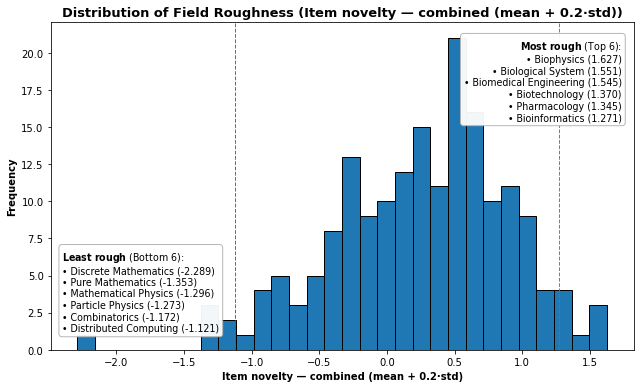

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Global config 
# -------------------------
TOP_K = 6                            # how many top/bottom fields to display
VAR_TO_USE = "items_nov_composite"   # Choose one of: "items_nov_mean", "items_nov_median", "items_nov_composite"

# -------------------------
# Name/ID column detection 
# -------------------------
CANDIDATE_NAME_COLS = ["concept_name", "concept", "field", "name", "Field", "Name", "Concept"]
CANDIDATE_ID_COLS   = ["matched_concept_id", "concept_id", "id"]

NAME_COL = next((c for c in CANDIDATE_NAME_COLS if c in df.columns), None)
if NAME_COL is None:
    NAME_COL = next((c for c in CANDIDATE_ID_COLS if c in df.columns), None)
if NAME_COL is None:
    raise ValueError(
        "Couldn't find a name/ID column in df_complexity. "
        f"Expected one of: {CANDIDATE_NAME_COLS + CANDIDATE_ID_COLS}"
    )

# -------------------------
# Ensure composite exists if chosen 
# -------------------------
MEAN_COL = "items_nov_mean"
STD_COL  = "items_nov_std"
COMB_COL = "items_nov_composite"

if VAR_TO_USE == COMB_COL and COMB_COL not in df.columns:
    if MEAN_COL not in df.columns or STD_COL not in df.columns:
        raise ValueError(
            f"To compute '{COMB_COL}', columns '{MEAN_COL}' and '{STD_COL}' must be present."
        )
    df[COMB_COL] = df[MEAN_COL] + 0.2 * df[STD_COL]

# -------------------------
# Validate choice 
# -------------------------
valid_vars = [MEAN_COL, "items_nov_median", COMB_COL]
if VAR_TO_USE not in valid_vars:
    raise ValueError(f"VAR_TO_USE must be one of {valid_vars}. Got: {VAR_TO_USE}")

# -------------------------    
# Build the ranking series
s = (
    df[[NAME_COL, VAR_TO_USE]]
    .dropna(subset=[VAR_TO_USE])
    .set_index(NAME_COL)[VAR_TO_USE]
)
# -------------------------

# Handle edge case: fewer rows than TOP_K
k_top = min(TOP_K, s.size)

topk    = s.nlargest(k_top)
bottomk = s.nsmallest(k_top)

# -------------------------
# Formatted variable label 
# -------------------------
pretty_var = {
    "items_nov_mean":      "Item novelty — mean",
    "items_nov_median":    "Item novelty — median",
    "items_nov_composite": "Item novelty — combined (mean + 0.2·std)"
}[VAR_TO_USE]

# -------------------------
# Plot 
# -------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(s.values, bins=30, edgecolor="black")
ax.set_title(f"Distribution of Field Roughness ({pretty_var})", fontsize=13, weight="bold")
ax.set_xlabel(pretty_var, fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")

# Vertical markers at thresholds
if len(bottomk) > 0:
    ax.axvline(bottomk.max(), color="tab:red", ls="--", lw=1, alpha=0.9)
if len(topk) > 0:
    ax.axvline(topk.min(), color="tab:green", ls="--", lw=1, alpha=0.9)

# Annotation blocks
top_block = (
    r"$\bf{Most\ rough}$"
    + f" (Top {k_top}):\n"
    + "\n".join([f"• {k} ({v:.3f})" for k, v in topk.items()])
)
bot_block = (
    r"$\bf{Least\ rough}$"
    + f" (Bottom {k_top}):\n"
    + "\n".join([f"• {k} ({v:.3f})" for k, v in bottomk.items()])
)
ax.text(
    0.98, 0.95, top_block,
    transform=ax.transAxes, va="top", ha="right", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95)
)
ax.text(
    0.02, 0.05, bot_block,
    transform=ax.transAxes, va="bottom", ha="left", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95)
)

plt.tight_layout()
plt.show()

---

## 3.2 Regressions with interaction terms 

In [9]:
# Load dataset
df = pd.read_csv("df_interactions.csv")

In [10]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --------------------------
# Global config 
# --------------------------
IMPACT_VARS  = ["weighted_nb_citations","top_cited_10","top_cited_5","top_cited_1"]
NOVELTY_VARS = ["semantic_distance","new_word","new_word_comb","new_phrase","new_phrase_comb"]

AI_VARS = [
    # "share_ai_2023",            # current intensity (2023)
    # "growth_share_ai",          # 2005→2023 change
    "share_ai_mean_2005_2023"     # trajectory/average 
]

COMPLEXITY_SPECS = [
    "items_nov_median", "items_nov_mean", "items_nov_composite"  
]

CONTROLS = ["log_nb_publ_total"]          
CENTER_VARS = True                        # mean-center AI and Complexity before interacting
SHOW_SE = False                           # keep table lean (β with stars only)

START_Y, END_Y = 2005, 2023               

# --------------------------
# Build derived controls
# --------------------------
# log total publications
if "log_nb_publ_total" in CONTROLS and "log_nb_publ_total" not in df.columns and "nb_publ" in df.columns:
    def _to_num(x):
        if pd.isna(x): return np.nan
        return pd.to_numeric(re.sub(r"[\s\u00A0\u202F,]", "", str(x)), errors="coerce")
    df["log_nb_publ_total"] = np.log1p(df["nb_publ"].apply(_to_num))

# growth in AI share (2005→2023)
if "growth_share_ai" in AI_VARS and "growth_share_ai" not in df.columns:
    y0, y1 = START_Y, END_Y
    c0, c1 = f"share_ai_{y0}", f"share_ai_{y1}"
    if {c0, c1} <= set(df.columns):
        df["growth_share_ai"] = pd.to_numeric(df[c1], errors="coerce") \
                                  - pd.to_numeric(df[c0], errors="coerce")

# average AI share 2005–2023
if "share_ai_mean_2005_2023" in AI_VARS and "share_ai_mean_2005_2023" not in df.columns:
    share_cols = [c for c in df.columns if re.fullmatch(rf"share_ai_({START_Y}|{START_Y+1}|{START_Y+2}|20\d{{2}})", c)]
    # keep only 2005..2023 explicitly
    share_cols = [c for c in share_cols
                  if c.startswith("share_ai_") and START_Y <= int(c.split("_")[-1]) <= END_Y]
    if share_cols:
        df["share_ai_mean_2005_2023"] = df[share_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# --------------------------
# Clean outcomes (strip stars -> float)
# --------------------------
def _to_num_beta(x):
    if pd.isna(x): return np.nan
    return pd.to_numeric(re.sub(r"\*", "", str(x)), errors="coerce")

for yv in IMPACT_VARS + NOVELTY_VARS:
    if yv in df.columns:
        df[yv] = df[yv].apply(_to_num_beta)

# --------------------------
# Interaction helpers
# --------------------------
def stars(p):  # 10%/5%/1%
    return "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""

def fit_interaction(df, yvar, ai, comp, controls, center=True, show_se=False):
    ctrls = [c for c in controls if c in df.columns]
    cols  = [yvar, ai, comp] + ctrls
    d = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty: return None, None

    A = d[ai].astype(float)
    C = d[comp].astype(float)
    if center:
        A = A - A.mean()
        C = C - C.mean()

    X = pd.DataFrame({"AI":A, "C":C, "AIxC":A*C}, index=d.index)
    for c in ctrls: X[c] = d[c].astype(float)
    X = sm.add_constant(X)
    y = d[yvar].astype(float)

    m = sm.OLS(y, X).fit()

    def fmt(name):
        if name not in m.params.index: return ""
        b, p = m.params[name], m.pvalues[name]
        if show_se:
            return f"{b:.3f}{stars(p)} ({m.bse[name]:.3f})"
        return f"{b:.3f}{stars(p)}"

    # Marginal effects of AI at p25/p50/p75 of C (on original scale)
    c_vals = np.nanpercentile(d[comp].astype(float), [25, 50, 75])
    b_ai  = m.params.get("AI", np.nan)
    b_int = m.params.get("AIxC", np.nan)
    c_mean = d[comp].astype(float).mean() if center else 0.0
    me = {lab: f"{(b_ai + b_int*(cv - c_mean)):.3f}" for lab, cv in zip(["ME_AI@p25","ME_AI@p50","ME_AI@p75"], c_vals)}

    row = {
        "β_AI": fmt("AI"),
        "β_C": fmt("C"),
        "β_AI×C": fmt("AIxC"),
        **me,
        "AdjR²": f"{m.rsquared_adj:.3f}",
        "N": f"{int(m.nobs)}"
    }
    return row, m

def run_block(df, outcomes, ai, comp, controls, center=True, show_se=False):
    rows, models = [], {}
    for y in outcomes:
        res, m = fit_interaction(df, y, ai, comp, controls, center=center, show_se=show_se)
        models[y] = m
        if res is None:
            rows.append({"Outcome": y, "β_AI":"", "β_C":"", "β_AI×C":"", "ME_AI@p25":"", "ME_AI@p50":"", "ME_AI@p75":"", "AdjR²":"", "N":""})
        else:
            rows.append({"Outcome": y, **res})
    return pd.DataFrame(rows), models

# Define labels
LAB_AI = {
    "share_ai_2023":              "AI share (2023)",
    "growth_share_ai":            "Δ AI share (23–05)",
    "share_ai_mean_2005_2023":    "AI share (avg 05–23)",
}
LAB_C = {
    "items_nov_median": "Complexity (items, median)",
    "items_nov_mean":   "Complexity (items, mean)",
    "items_nov_composite": "Complexity (items, composite)"
}

# --------------------------
# Run and print tables
# --------------------------
IMPACT_EXIST  = [v for v in IMPACT_VARS  if v in df.columns]
NOVELTY_EXIST = [v for v in NOVELTY_VARS if v in df.columns]

for ai in AI_VARS:
    if ai not in df.columns:
        print(f"[skip] AI var missing: {ai}")
        continue
    for comp in COMPLEXITY_SPECS:
        if comp not in df.columns:
            print(f"[skip] Complexity var missing: {comp}")
            continue

        ctrl_present = [c for c in CONTROLS if c in df.columns]

        impact_tbl, _  = run_block(df, IMPACT_EXIST,  ai, comp, ctrl_present, center=CENTER_VARS, show_se=SHOW_SE)
        novelty_tbl, _ = run_block(df, NOVELTY_EXIST, ai, comp, ctrl_present, center=CENTER_VARS, show_se=SHOW_SE)

        with pd.option_context("display.max_columns", None, "display.width", 200):
            print(f"\n=== IMPACT — {LAB_AI.get(ai, ai)} × {LAB_C.get(comp, comp)} | Controls: {', '.join(ctrl_present) or 'none'} | Center={CENTER_VARS}")
            print(impact_tbl.to_string(index=False))
            print(f"\n=== NOVELTY — {LAB_AI.get(ai, ai)} × {LAB_C.get(comp, comp)} | Controls: {', '.join(ctrl_present) or 'none'} | Center={CENTER_VARS}")
            print(novelty_tbl.to_string(index=False))


=== IMPACT — AI share (avg 05–23) × Complexity (items, median) | Controls: log_nb_publ_total | Center=True
              Outcome   β_AI      β_C β_AI×C ME_AI@p25 ME_AI@p50 ME_AI@p75  AdjR²   N
weighted_nb_citations  0.023 -0.009**  0.032     0.010     0.027     0.038  0.052 172
         top_cited_10 -0.025   -0.002  0.076    -0.057    -0.015     0.010 -0.013 172
          top_cited_5  0.047    0.009  0.055     0.023     0.054     0.072  0.007 172
          top_cited_1  0.108    0.003  0.138     0.050     0.126     0.171  0.015 172

=== NOVELTY — AI share (avg 05–23) × Complexity (items, median) | Controls: log_nb_publ_total | Center=True
          Outcome      β_AI       β_C   β_AI×C ME_AI@p25 ME_AI@p50 ME_AI@p75 AdjR²   N
semantic_distance -0.047***  0.002***   -0.005    -0.045    -0.048    -0.049 0.529 172
         new_word  0.475***  -0.065**  0.386**     0.300     0.516     0.640 0.165 143
    new_word_comb  0.774*** -0.126*** 0.786***     0.427     0.865     1.124 0.389 147
     

## 3.3 Plots marginal effects 

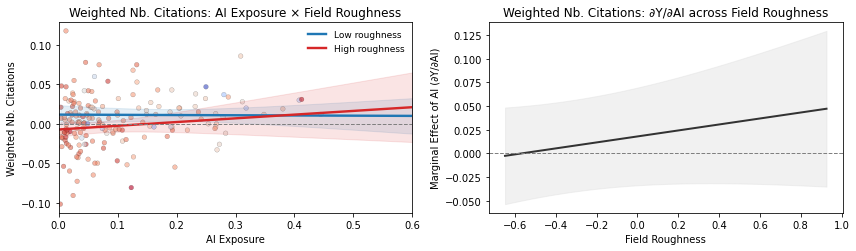

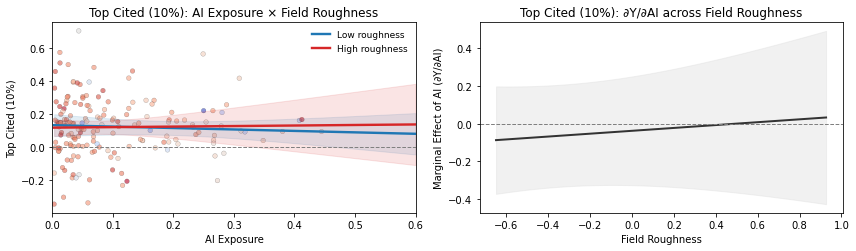

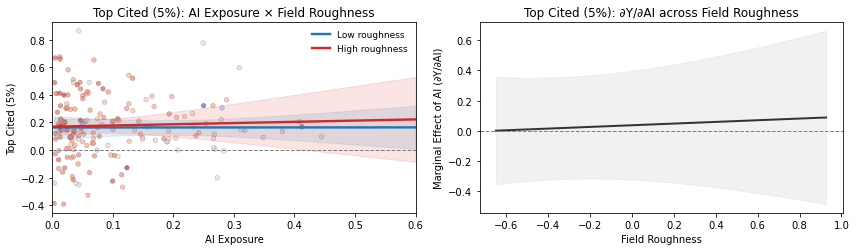

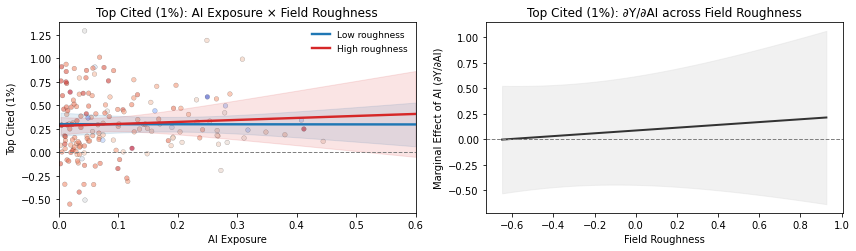

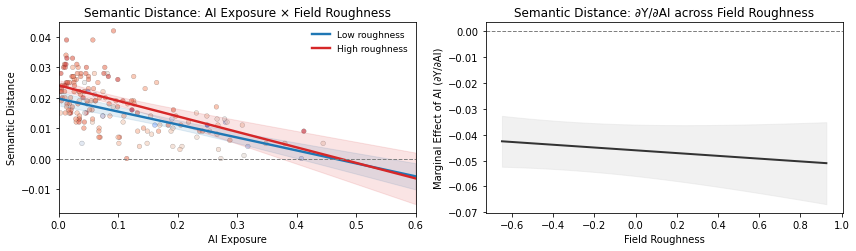

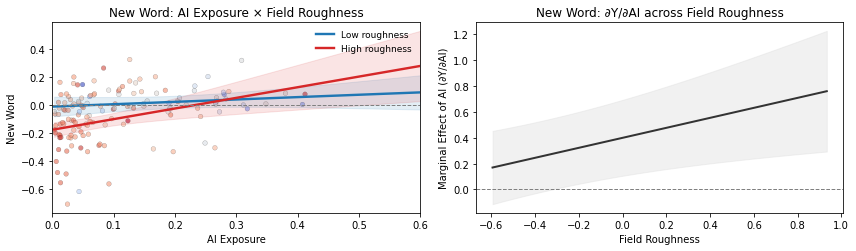

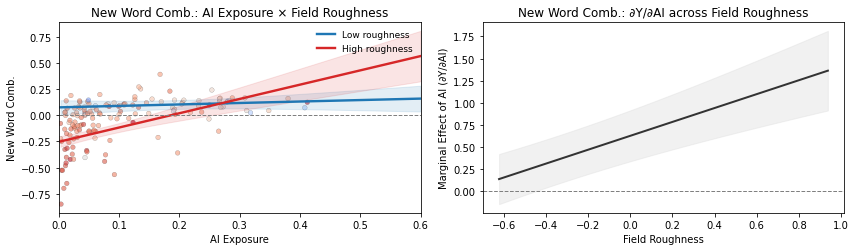

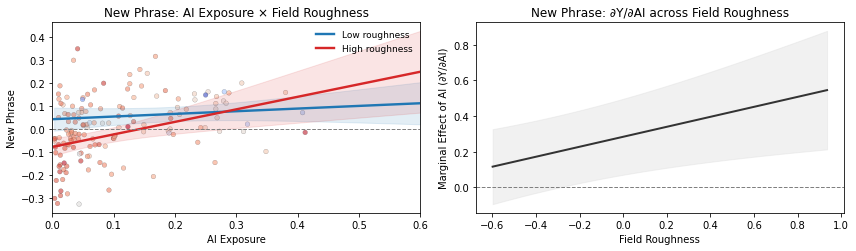

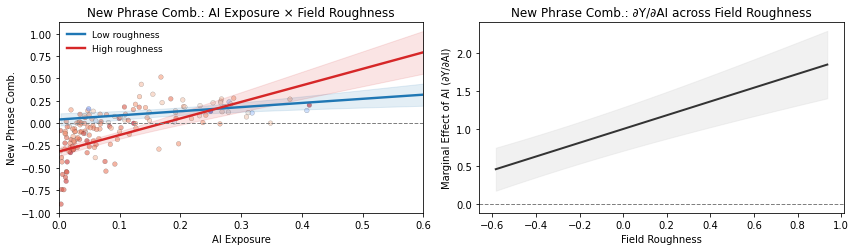

In [11]:
import numpy as np, pandas as pd, statsmodels.api as sm
import matplotlib.pyplot as plt
import re

# --------------------------
# Config 
# --------------------------
AI_VAR    = "share_ai_mean_2005_2023"   # or: "share_ai_2023"
ROUGH_VAR = "items_nov_median"          # field roughness
CONTROLS  = ["log_nb_publ_total"]       # optional; ignored if absent
OUTCOMES  = [
    "weighted_nb_citations","top_cited_10","top_cited_5","top_cited_1",
    "semantic_distance","new_word","new_word_comb","new_phrase","new_phrase_comb"
]
CENTER    = True
CI_LEVEL  = 0.95
X_MAX     = 0.60            # fix left x-axis to [0, X_MAX]
LOW_PCT   = 10              # low roughness percentile
HIGH_PCT  = 90              # high roughness percentile
SCATTER_CMAP = "coolwarm"   # gradient for scatter points (blue→red)

# Define labels
VAR_LABELS = {
    "weighted_nb_citations": "Weighted Nb. Citations",
    "top_cited_10":          "Top Cited (10%)",
    "top_cited_5":           "Top Cited (5%)",
    "top_cited_1":           "Top Cited (1%)",
    "semantic_distance":     "Semantic Distance",
    "new_word":              "New Word",
    "new_word_comb":         "New Word Comb.",
    "new_phrase":            "New Phrase",
    "new_phrase_comb":       "New Phrase Comb.",
}

START_Y, END_Y = 2005, 2023  

# --------------------------
# Controls
# --------------------------
# Build log_nb_publ_total if missing
if "log_nb_publ_total" in CONTROLS and "log_nb_publ_total" not in df.columns:
    def _to_num(x):
        if pd.isna(x): return np.nan
        return pd.to_numeric(re.sub(r"[\s\u00A0\u202F,]", "", str(x)), errors="coerce")
    if "nb_publ" in dfI.columns:
        dfI["log_nb_publ_total"] = np.log1p(df["nb_publ"].apply(_to_num))

# Build AI average 2005–2023 if selected but missing
if AI_VAR == "share_ai_mean_2005_2023" and "share_ai_mean_2005_2023" not in df.columns:
    share_cols = [c for c in df.columns if re.fullmatch(r"share_ai_(19|20)\d{2}", c)]
    share_cols = [c for c in share_cols if START_Y <= int(c.split("_")[-1]) <= END_Y]
    if share_cols:
        dfI["share_ai_mean_2005_2023"] = dfI[share_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# --------------------------
# Helpers
# --------------------------
def fit_interaction(df, yvar, ai, rough, controls=(), center=True):
    ctrls = [c for c in controls if c in df.columns]
    cols  = [yvar, ai, rough] + ctrls
    d = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty:
        return None, None, (0.0, 0.0)
    A = d[ai].astype(float); R = d[rough].astype(float)
    Am, Rm = A.mean(), R.mean()
    if center:
        A = A - Am; R = R - Rm
    X = pd.DataFrame({"AI": A, "Rough": R, "AIxR": A*R}, index=d.index)
    for c in ctrls: X[c] = d[c].astype(float)
    X = sm.add_constant(X)
    y = d[yvar].astype(float)
    m = sm.OLS(y, X).fit()
    return m, d, (Am if center else 0.0, Rm if center else 0.0)

def me_line(model, r_vals, r_mean):
    b, V = model.params, model.cov_params()
    b_ai  = b.get("AI", np.nan); b_int = b.get("AIxR", np.nan)
    me = b_ai + (r_vals - r_mean) * b_int
    v_ai  = V.loc["AI","AI"]     if "AI"   in V.index else np.nan
    v_int = V.loc["AIxR","AIxR"] if "AIxR" in V.index else np.nan
    cov   = V.loc["AI","AIxR"]   if {"AI","AIxR"} <= set(V.index) else 0.0
    var   = v_ai + (r_vals - r_mean)**2 * v_int + 2*(r_vals - r_mean)*cov
    se = np.sqrt(np.maximum(var, 0))
    return me, se

# --------------------------
# Plotting
# --------------------------
def plot_two_panel_low_high(df, outcomes, ai, rough, controls=(), center=True,
                            low_pct=10, high_pct=90, ci=0.95, x_max=0.6):
    z = 1.96 if abs(ci-0.95)<1e-9 else sm.stats.norm.ppf(0.5+ci/2)
    for yvar in outcomes:
        m, d, (Am, Rm) = fit_interaction(df, yvar, ai, rough, controls, center=center)
        title = VAR_LABELS.get(yvar, yvar)
        if m is None:
            print(f"[skip] No usable data for {title}")
            continue

        # Roughness cutoffs (customizable)
        r_low, r_high = np.nanpercentile(d[rough].astype(float), [low_pct, high_pct])

        # Grid for AI exposure (bounded by data & X_MAX)
        a_min, a_max = d[ai].astype(float).min(), d[ai].astype(float).max()
        ai_grid = np.linspace(max(0.0, a_min), min(x_max, a_max), 200)

        fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.6))

        # --- Left: scatter + predicted lines (blue/red) ---
        axL.scatter(
            d[ai].astype(float), d[yvar].astype(float),
            c=d[rough].astype(float), cmap=SCATTER_CMAP,
            s=22, alpha=0.6, edgecolor="k", linewidth=0.2
        )

        for (lab, r0, col) in [
            ("Low roughness",  r_low,  "tab:blue"),
            ("High roughness", r_high, "tab:red"),
        ]:
            A = ai_grid - (Am if center else 0)
            R = np.full_like(ai_grid, r0 - (Rm if center else 0))
            Xp = pd.DataFrame({"const":1.0, "AI":A, "Rough":R, "AIxR":A*R})
            for ctrl in [c for c in controls if c in d.columns]:
                Xp[ctrl] = d[ctrl].mean()
            pred = m.get_prediction(Xp)
            yhat, se = pred.predicted_mean, pred.se_mean
            axL.plot(ai_grid, yhat, lw=2.4, color=col, label=lab)
            axL.fill_between(ai_grid, yhat - z*se, yhat + z*se, alpha=0.12, color=col)

        axL.set_xlim(0, x_max)
        axL.set_xlabel("AI Exposure")
        axL.set_ylabel(title)
        axL.set_title(f"{title}: AI Exposure × Field Roughness")
        axL.axhline(0, ls="--", lw=1, color="grey")
        axL.legend(frameon=False, fontsize=9)

        # --- Right: marginal effect across roughness (neutral greys) ---
        r_vals = np.linspace(r_low, r_high, 200)
        me, se = me_line(m, r_vals, Rm if center else 0.0)
        axR.plot(r_vals, me, lw=2, color="#333333")                 
        axR.fill_between(r_vals, me - z*se, me + z*se, alpha=0.35,
                         color="#d9d9d9")                            
        axR.axhline(0, ls="--", lw=1, color="grey")
        axR.set_xlabel("Field Roughness")
        axR.set_ylabel("Marginal Effect of AI (∂Y/∂AI)")
        axR.set_title(f"{title}: ∂Y/∂AI across Field Roughness")

        fig.tight_layout()
        plt.show()

# --------------------------
# Run everything
# --------------------------
plot_two_panel_low_high(
    df,
    outcomes=OUTCOMES,
    ai=AI_VAR,
    rough=ROUGH_VAR,
    controls=CONTROLS,
    center=CENTER,
    low_pct=LOW_PCT,
    high_pct=HIGH_PCT,
    ci=CI_LEVEL,
    x_max=X_MAX
)

---

# 4. Analysis by period

<u>What the dashboard shows</u>:  
This 8-panel figure summarizes the regression-based relationship between AI adoption and two dimensions of scientific performance (**novelty** and **impact**) across fields and time. 

See Section 2 of the code for details on how to interpret the plot.

[info] periods found: 2005_2012, 2013_2017, 2018_2022, 2023


/var/folders/9w/6cd0lh8j717c_lsxk7qkl7t80000gn/T/ipykernel_3419/2965497221.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


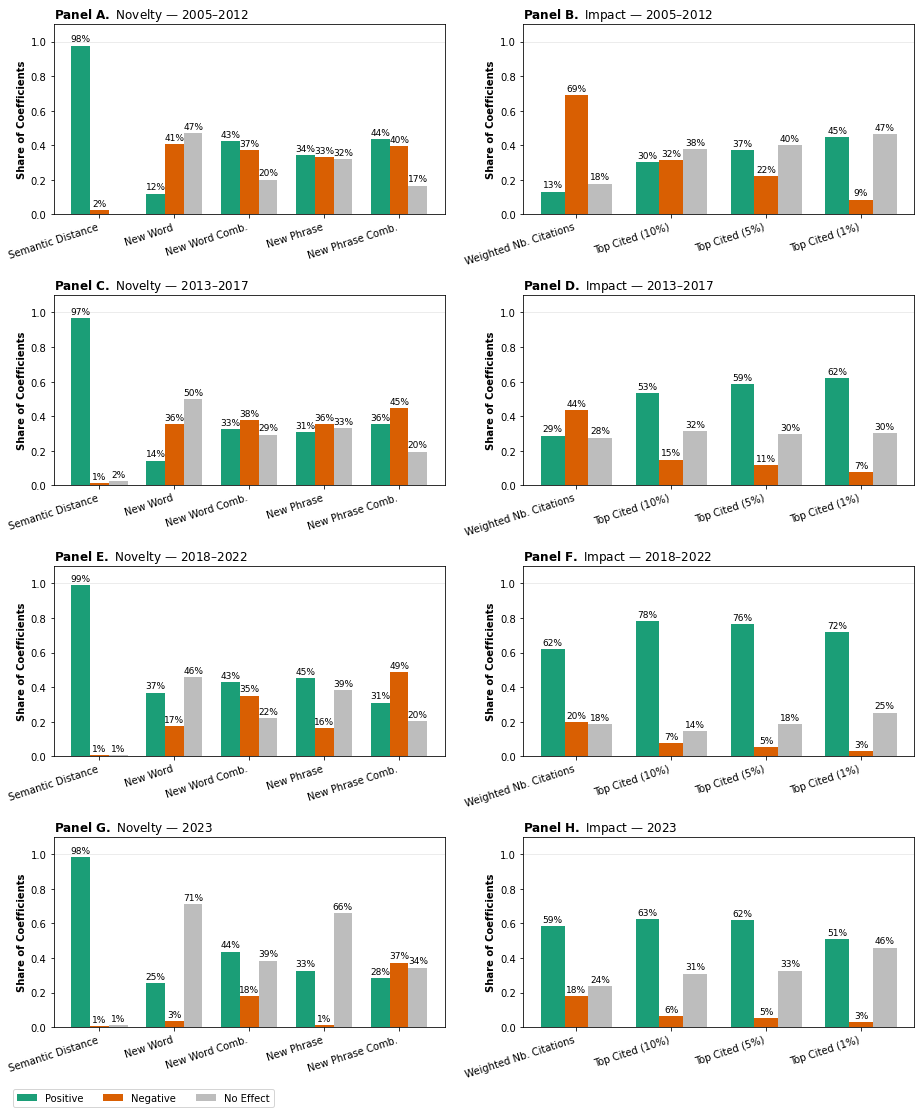

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# Configuration 
# ------------------------
CSV_PATH   = "df_descriptives_by_period.csv"
SAVE_ALL   = True
ALL_PNG    = "Panels_AtoH_by_period.png"

# Force the four periods (now using 2013–2017)
PERIODS = ["2005_2012", "2013_2017", "2018_2022", "2023"]

IMPACT_VARS = {
    "nb_citations": "Weighted Nb. Citations",
    "top10":        "Top Cited (10%)",
    "top5":         "Top Cited (5%)",
    "top1":         "Top Cited (1%)",
}
NOVELTY_VARS = {
    "semantic_distance": "Semantic Distance",
    "new_word":          "New Word",
    "new_word_comb":     "New Word Comb.",
    "new_phrase":        "New Phrase",
    "new_phrase_comb":   "New Phrase Comb.",
}
IMPACT_ORDER  = ["nb_citations", "top10", "top5", "top1"]
NOVELTY_ORDER = ["semantic_distance", "new_word", "new_word_comb", "new_phrase", "new_phrase_comb"]

CATS       = ["pos_significant", "neg_significant", "no_effect"]
CAT_LABELS = {"pos_significant":"Positive", "neg_significant":"Negative", "no_effect":"No Effect"}
COLORS     = {"pos_significant":"#1b9e77", "neg_significant":"#d95f02", "no_effect":"#bdbdbd"}

# ------------------------
# Helpers 
# ------------------------
beta_pat = re.compile(r"^beta_(\d{4}(?:_\d{4})?)_(.+)$")
coef_re  = re.compile(r"^\s*([+-]?\d*\.?\d+)(\*+)?\s*$")

def find_periods_and_vars(columns):
    per_map = {}
    for c in columns:
        m = beta_pat.match(c)
        if not m:
            continue
        per, var = m.group(1), m.group(2)
        per_map.setdefault(per, {})[var] = c
    return per_map

def classify_coef(cell):
    if pd.isna(cell): return "no_effect"
    m = coef_re.match(str(cell))
    if not m: return "no_effect"
    val = float(m.group(1)); stars = m.group(2)
    if stars:
        if val > 0: return "pos_significant"
        if val < 0: return "neg_significant"
    return "no_effect"

def shares_for_period(dfp, period, family_map, order):
    cols = {k: f"beta_{period}_{k}" for k in order if f"beta_{period}_{k}" in dfp.columns}
    if not cols:
        return pd.DataFrame(columns=CATS)
    classified = pd.DataFrame({
        family_map[k]: dfp[cols[k]].map(classify_coef) for k in cols.keys()
    })
    long = classified.melt(var_name="variable", value_name="category")
    long.loc[~long["category"].isin(CATS), "category"] = "no_effect"
    share_tbl = (
        pd.crosstab(long["variable"], long["category"], normalize="index")
          .reindex(columns=CATS, fill_value=0.0)
    )
    share_tbl = share_tbl.reindex([family_map[k] for k in order if k in cols], fill_value=0.0)
    return share_tbl

def plot_grouped_bars(ax, share_tbl, title_text):
    if share_tbl.empty:
        ax.axis("off"); ax.text(0.5, 0.5, "No data", ha="center", va="center")
        return
    x = np.arange(len(share_tbl.index)); w = 0.25
    for i, cat in enumerate(CATS):
        vals = share_tbl[cat].values
        bars = ax.bar(x + i*w, vals, width=w, label=CAT_LABELS[cat], color=COLORS[cat])
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
                        f"{v*100:.0f}%", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x + w, share_tbl.index, rotation=18, ha="right")
    ax.set_ylim(0, 1.10)
    ax.set_ylabel("Share of Coefficients", fontweight="bold")
    ax.set_xlabel("")
    ax.axhline(1.0, color="0.88", lw=0.6)
    ax.set_title(title_text, loc="left")

# ------------------------
# Load data
# ------------------------
dfp = pd.read_csv(CSV_PATH)
dfp.columns = [c.strip() for c in dfp.columns]
per_map = find_periods_and_vars(dfp.columns)

# Restrict to the four target periods 
periods = [p for p in PERIODS if any(c.startswith(f"beta_{p}_") for c in dfp.columns)]
if not periods:
    raise ValueError("None of the target periods found in the CSV!")

print("[info] periods found:", ", ".join(periods))

# ------------------------
# Plot (rows = periods; sequential labels A–H) 
# ------------------------
rows = len(periods)
fig, axes = plt.subplots(rows, 2, figsize=(13, 3.8*rows), constrained_layout=True)
if rows == 1:
    axes = np.array([axes])  # ensure 2D

for i, per in enumerate(periods):
    per_label   = per.replace("_", "–")
    left_letter = chr(ord("A") + 2*i)
    right_letter= chr(ord("A") + 2*i + 1)

    nov_tbl = shares_for_period(dfp, per, NOVELTY_VARS, NOVELTY_ORDER)
    imp_tbl = shares_for_period(dfp, per, IMPACT_VARS,  IMPACT_ORDER)

    plot_grouped_bars(
        axes[i, 0], nov_tbl,
        rf"$\bf{{Panel\ {left_letter}.}}$ Novelty — {per_label}"
    )
    plot_grouped_bars(
        axes[i, 1], imp_tbl,
        rf"$\bf{{Panel\ {right_letter}.}}$ Impact — {per_label}"
    )

# Shared legend (bottom)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="lower left",
           bbox_to_anchor=(0.02, -0.02), frameon=True)

plt.tight_layout()
plt.show()